#Decision Trees

**Objective: Learn how to apply the decision trees.**

Decision trees are widely used in the banking industry due to their high accuracy and ability to formulate a model in plain language. Since government organizations in many countries carefully monitor lending practices, banks must be able to explain why one applicant was rejected for a loan while the others were approved.

In this lab, we will develop a simple credit approval model using decision trees.

**Source: Lantz Brett, Machine Learning with R. Packt Publishing**

# I. Collecting data

The idea behind our credit model is to identify factors that are predictive of higher risk of default.

We will use a Data available in a dataset donated to the UCI Machine Learning Data Repository by Hans Hofmann of the University of Hamburg.

The dataset contains information on loans obtained from a credit agency in Germany.

The credit dataset includes 1,000 examples on loans, plus a set of numeric and nominal features indicating the characteristics of the loan and the loan applicant.

A class variable indicates whether the loan went into default.


# II. Exploring and preparing the data

## A. Exploring the data

Let’s import the data. The data is available on Canvas, named **credit.csv**.

**1. Import and read the csv data file.**

**2. Examine the structure of the data frame.**

**3.  Which features can be a possible predictor of a default loan?**

**4. How can you check and study those features? Explain.**

**5.  What percentage of the loans in the dataset went into default? is it high? How this result can aﬀect the loaning bank?**

## B. Data preparation

**6.Convert categorical data into numerical.**

**7. Check if your dataset is randomized.**

# III. Training a model on the data

**8. Split the data into training and testing sets.**

**9. Apply the decision tree algorithm.**

**10. Visualize the model after training**

**11. Find the best predictor features.**

# IV. Evaluating model performance

**12. Check the accuracy of the model. Check other metrics.**

**13. Is this model a good model?**

# V. Improving model performance

**14. How can you improve the performance of your decision tree model?**

**15. Apply different ways of improve the model. Discuss and explain your results.**

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('credit-1.csv')
df.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 DM,42,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 DM,24,poor,car,4870,< 100 DM,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes


In [40]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_duration   1000 non-null   object
 7   percent_of_income     1000 non-null   int64 
 8   years_at_residence    1000 non-null   int64 
 9   age                   1000 non-null   int64 
 10  other_credit          1000 non-null   object
 11  housing               1000 non-null   object
 12  existing_loans_count  1000 non-null   int64 
 13  job                   1000 non-null   object
 14  dependents            1000 non-null   int64 
 15  phone                 1000 non-null   o

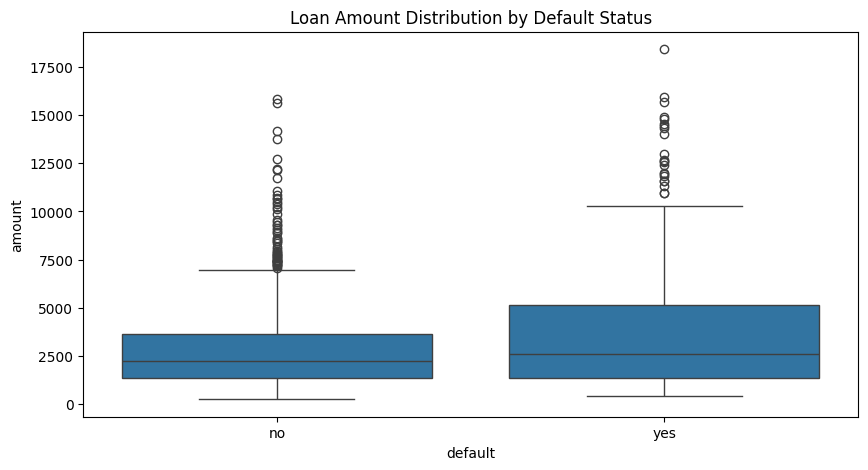

In [41]:
# From the data I think that the balance the person has makes a good predictor
# And also the person's credit history make an high impact on the same.
# Also by age amount it makes a impact on the account going default.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.boxplot(x='default', y='amount', data=df)
plt.title('Loan Amount Distribution by Default Status')
plt.show()

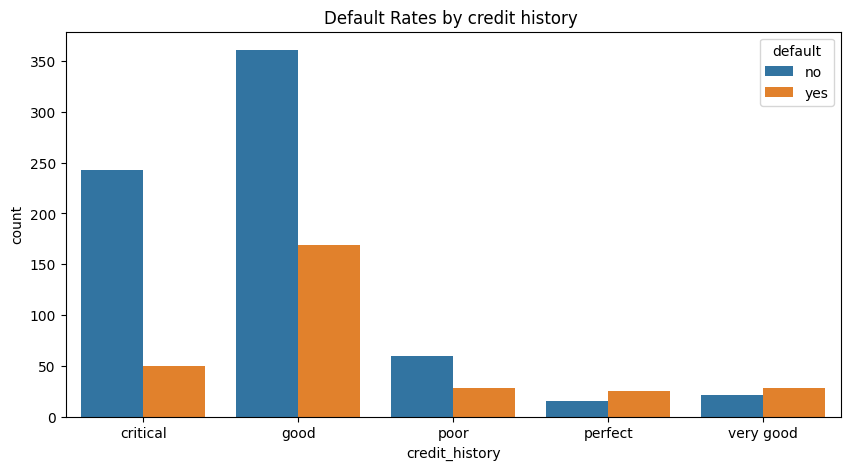

In [42]:
# Checking it with credit history
plt.figure(figsize=(10, 5))
sns.countplot(x='credit_history', hue='default', data=df)
plt.title('Default Rates by credit history ')
plt.show()

In [43]:
default_counts = df['default'].value_counts(normalize=True) * 100
print("Default Percentage:")
print(default_counts)

# We have a 30% default rate in this database which is a high risk

# This can directly reduce the banks profit, having them a risk of icreasing the interests for future customers and also patnering
#with recovery agencies to seize the assets from the default clients in order to make the principal back

Default Percentage:
default
no     70.0
yes    30.0
Name: proportion, dtype: float64


In [44]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('default')

X = pd.get_dummies(df.drop('default', axis=1), columns=categorical_cols, drop_first=True)
y = df['default'].map({'yes': 1, 'no': 0}) # Encoding target: 1 for default, 0 for no

print(f"Features after encoding: {X.shape[1]}")

Features after encoding: 35


In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

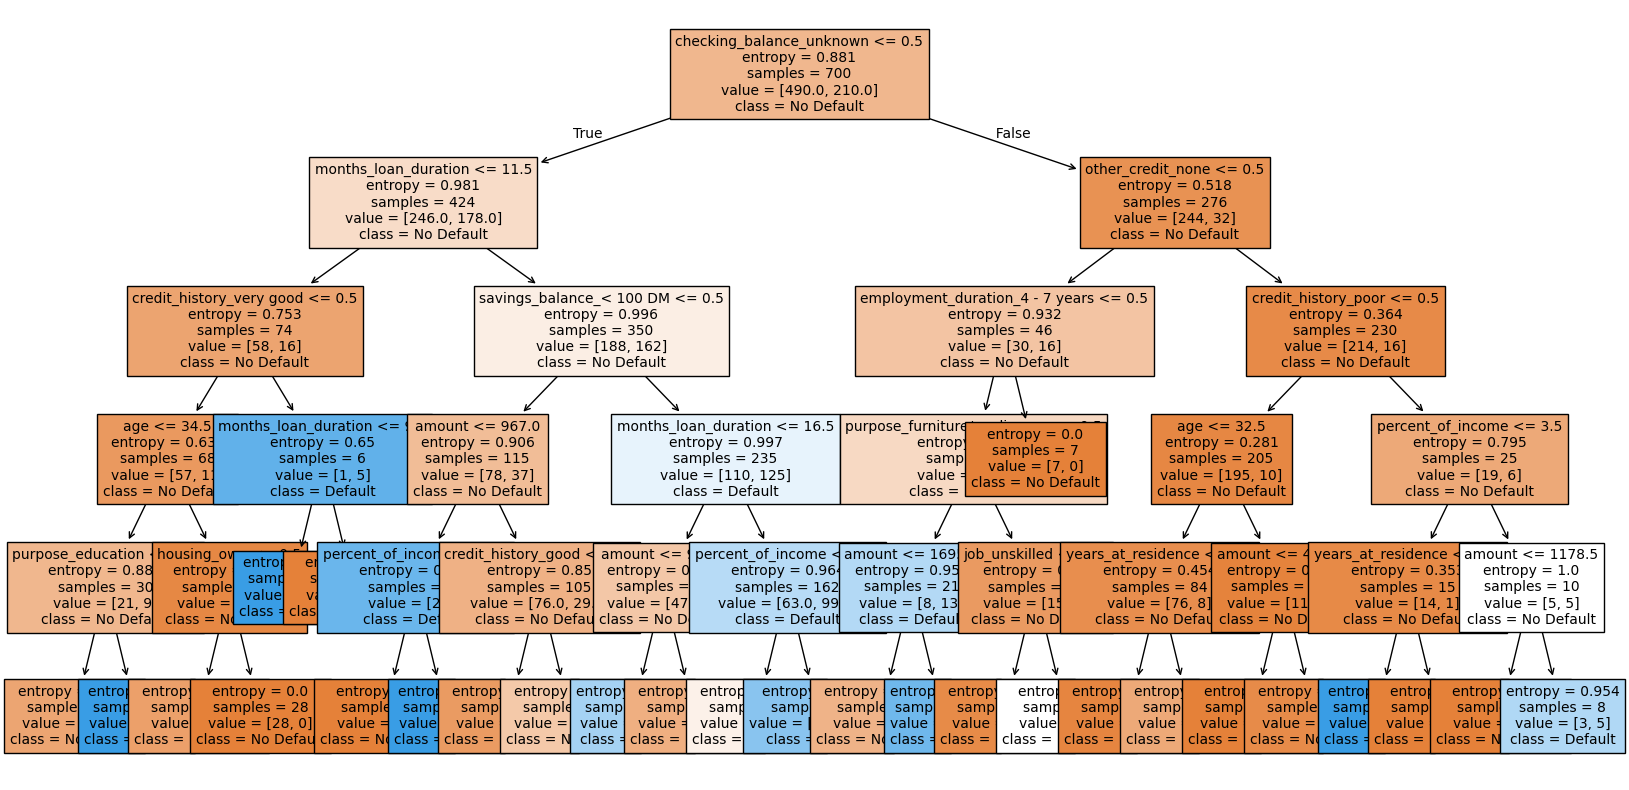


Top Predictor Features:
                     Feature  Importance
9   checking_balance_unknown    0.269310
0       months_loan_duration    0.117132
1                     amount    0.110657
2          percent_of_income    0.087478
27         other_credit_none    0.075223
3         years_at_residence    0.050818
4                        age    0.048840
20  savings_balance_< 100 DM    0.046826
13  credit_history_very good    0.039117
12       credit_history_poor    0.029128


In [46]:

plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=['No Default', 'Default'], filled=True, fontsize=10)
plt.show()

importances = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
importances = importances.sort_values(by='Importance', ascending=False)
print("\nTop Predictor Features:")
print(importances.head(10))

DATA IS RANDOMIZED ALREADY

In [47]:
# accuracy and metrics
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.67

Confusion Matrix:
[[169  41]
 [ 58  32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.80      0.77       210
           1       0.44      0.36      0.39        90

    accuracy                           0.67       300
   macro avg       0.59      0.58      0.58       300
weighted avg       0.65      0.67      0.66       300



In [48]:
# LETS try to improve

from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Improved Accuracy: {best_model.score(X_test, y_test):.2f}")

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}
Improved Accuracy: 0.67


## PART 2

During this exercise, I learned that building a machine learning environment is about a lot more than just clicking "train." When I started with the raw data, I first ran into a frustrating issue where the model only seemed to care about only one thing the checking balance. I realized that this was because I wasn’t properly translating text-based information into a format that the computer could actually use, which caused it to miss almost all useful information. After figuring out the data preparation and using a search engine to find the best settings for the model, the process was very smooth. The accuracy reached about 67%, and the model finally started looking at various factors such as how long ago the loan was made and the person’s credit history. The biggest challenge was definitely the data cleaning part, but it taught me that the quality of what you put into the model is really what determines the quality of the answers you get.